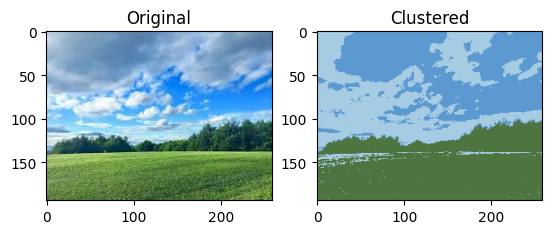

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("image.jpeg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Reshape image to 2D array
Z = img.reshape((-1,3))
Z = np.float32(Z)

# Apply K-Means
K = 3
_, label, center = cv2.kmeans(Z, K, None,
                              (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,10,1.0),
                              10, cv2.KMEANS_RANDOM_CENTERS)

# Convert centers back to uint8
center = np.uint8(center)

# Recreate clustered image
res = center[label.flatten()]
clustered = res.reshape(img.shape)

# Display results
plt.subplot(121), plt.imshow(img), plt.title("Original")
plt.subplot(122), plt.imshow(clustered), plt.title("Clustered")
plt.show()